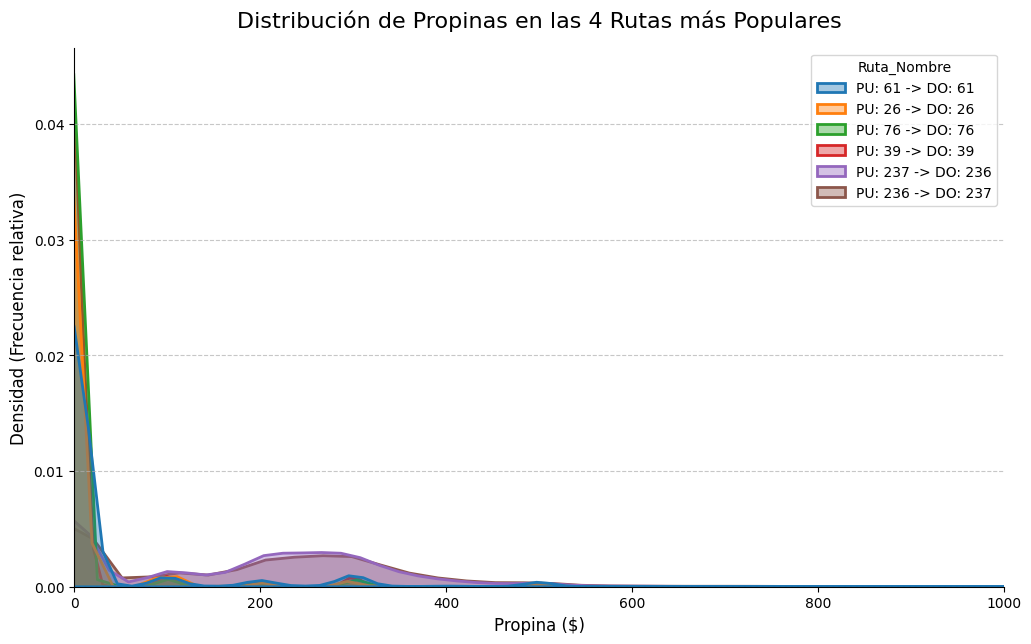

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

path = Path.cwd()
if not Path(path, "data").exists(): path = path.parent
df = pl.read_parquet(path / "data" / "train_tip.parquet")

columna_target = "tip_amount" 

# 2. Buscar las 4 rutas (Origen -> Destino) con MÁS viajes
rutas_frecuentes = (
    df.group_by(["PULocationID", "DOLocationID"])
    .len(name="total_viajes")
    .sort("total_viajes", descending=True)
    .head(6)
)

# Filtrar el dataset original para quedarnos SOLO con los viajes de esas 4 rutas
df_filtrado = df.join(rutas_frecuentes, on=["PULocationID", "DOLocationID"], how="inner")

# Crear una columna de texto bonito para la leyenda del gráfico (Ej: "Ruta 132 -> 230")
df_filtrado = df_filtrado.with_columns(
    (pl.lit("PU: ") + pl.col("PULocationID").cast(pl.String) + 
     pl.lit(" -> DO: ") + pl.col("DOLocationID").cast(pl.String)).alias("Ruta_Nombre")
)

# Pasar a Pandas SOLO las dos columnas que necesitamos para el gráfico (Zero-Copy)
df_plot = df_filtrado.select(["Ruta_Nombre", columna_target]).to_pandas()

# Dibujar las distribuciones (KDE Density Plot)
plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=df_plot, 
    x=columna_target, 
    hue="Ruta_Nombre", 
    fill=True, 
    common_norm=False, # Para que todas las curvas sean igual de altas y fáciles de comparar
    alpha=0.4,
    linewidth=2,
    palette="tab10"
)

plt.title("Distribución de Propinas en las 4 Rutas más Populares", fontsize=16, pad=15)
plt.xlabel("Propina ($)", fontsize=12)
plt.ylabel("Densidad (Frecuencia relativa)", fontsize=12)

plt.xlim(0, 1000) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine() # Quita los bordes feos de arriba y la derecha
plt.show()

Vemos que las distribuciones son multimodales por lo que un modelo que prediga un valor de propina tenderá a predecir la media global pero no representará fielmente la distribución.